# M&A Success Prediction
**Databases used:**
- `Acquisitions.csv`
- `Acquired Tech Companies.csv`
- `Acquiring Tech Companies.csv`
- `Founders and Board Members.csv`

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import timedelta
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print('✅ Libraries loaded')

✅ Libraries loaded


## 2. Load Data

In [5]:
acq         = pd.read_csv('Acquisitions.csv')
target_df   = pd.read_csv('Acquired Tech Companies.csv')
acquirer_df = pd.read_csv('Acquiring Tech Companies.csv')
founders_df = pd.read_csv('Founders and Board Members.csv')

# Parse deal date & drop rows without it
acq['Deal announced on'] = pd.to_datetime(acq['Deal announced on'], errors='coerce')
acq = acq.dropna(subset=['Deal announced on']).reset_index(drop=True)

# Clean Price column (handles 'Undisclosed amount' strings)
acq['Price'] = pd.to_numeric(acq['Price'], errors='coerce')

print(f'Acquisitions : {len(acq):,} rows')
print(f'Acquired     : {len(target_df):,} rows')
print(f'Acquirers    : {len(acquirer_df):,} rows')
print(f'Founders     : {len(founders_df):,} rows')

Acquisitions : 742 rows
Acquired     : 1,610 rows
Acquirers    : 36 rows
Founders     : 382 rows


## 3. Merge Datasets

In [6]:
# ── Merge target (acquired company) info ──────────────────────────────────
df = acq.merge(
    target_df[['Company', 'Year Founded', 'Market Categories',
               'Description', 'Country (HQ)']],
    left_on='Acquired Company', right_on='Company', how='left'
)
df = df.rename(columns={
    'Year Founded':      'target_founded',
    'Market Categories': 'target_cat',
    'Description':       'target_desc',
    'Country (HQ)':      'target_country'
})
df = df.drop(columns=['Company'], errors='ignore')

# ── Clean acquirer numeric columns ────────────────────────────────────────
acquirer_df['Number of Employees'] = (
    acquirer_df['Number of Employees']
    .astype(str).str.replace(',', '', regex=False)
)
acquirer_df['Number of Employees'] = pd.to_numeric(
    acquirer_df['Number of Employees'], errors='coerce'
)
acquirer_df['Total Funding ($)'] = pd.to_numeric(
    acquirer_df['Total Funding ($)'], errors='coerce'
)

# ── Merge acquirer info ───────────────────────────────────────────────────
df = df.merge(
    acquirer_df[['Acquiring Company', 'Year Founded', 'Number of Employees',
                 'Total Funding ($)', 'Number of Acquisitions',
                 'IPO', 'Market Categories', 'Description']],
    on='Acquiring Company', how='left'
)
df = df.rename(columns={
    'Year Founded':            'acquirer_founded',
    'Number of Employees':     'acquirer_employees',
    'Total Funding ($)':       'acquirer_total_funding',
    'Number of Acquisitions':  'acquirer_num_acquisitions',
    'IPO':                     'acquirer_ipo_year',
    'Market Categories':       'acquirer_cat',
    'Description':             'acquirer_desc'
})

print(f'Dataset after merge: {len(df):,} rows')
df.head(3)

Dataset after merge: 742 rows


,Acquisitions ID,Acquired Company,Acquiring Company,Year of acquisition announcement,Deal announced on,Price,Status,Terms,Acquisition Profile,News,...,target_cat,target_desc,target_country,acquirer_founded,acquirer_employees,acquirer_total_funding,acquirer_num_acquisitions,acquirer_ipo_year,acquirer_cat,acquirer_desc
0,[24]7 acquired Tellme in 2012,Tellme,[24]7,2012,2012-01-02,NaN,Undisclosed,Undisclosed,http://www.crunchbase.com/acquisition/a9e7a5ac...,Microsoft and 24/7 Inc. Join Forces to Deliver...,...,Mobile,Tellme provides voice recognition and instruct...,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3Com acquired Palm in 1997,Palm,3Com,1997,1997-01-06,NaN,Undisclosed,Undisclosed,http://www.crunchbase.com/acquisition/65869a9a...,Investors bless 3Com-USR merger - CNET News,...,Mobile,"Palm, Inc. was a leading mobile products compa...",United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Adobe Systems acquired Auditude in 2011,Auditude,Adobe,2011,2011-01-11,NaN,Undisclosed,Cash,http://www.crunchbase.com/acquisition/c6622ec6...,Adobe acquires video ad platform Auditude for ...,...,"Monetization, Advertising, Video",Auditude is a leading video management and mon...,United States,1982.0,11144.0,0.0,38.0,1986,"Photo Editing, Design, Creative, Software, Ima...",Adobe Systems is an American multinational com...


## 4. Founders & Board Member Features

In [7]:
founders_df['is_founder'] = founders_df['Role'].str.contains(
    'Founder', case=False, na=False).astype(int)
founders_df['is_board'] = founders_df['Role'].str.contains(
    'Board', case=False, na=False).astype(int)

founder_counts = (
    founders_df.groupby('Companies')
    .agg(num_founders=('is_founder', 'sum'),
         num_board=('is_board', 'sum'))
    .reset_index()
    .rename(columns={'Companies': 'Acquiring Company'})
)

df = df.merge(founder_counts, on='Acquiring Company', how='left')
df['num_founders'] = df['num_founders'].fillna(0)
df['num_board']    = df['num_board'].fillna(0)

print('Founder/board counts merged:')
print(founder_counts.head(10))

Founder/board counts merged:
              Acquiring Company  num_founders  num_board
0                           AOL             3          9
1                   AOL, Google             0          1
2                          AT&T             1         11
3                AT&T, Vodafone             0          1
4                         Adobe             2         11
5                        Amazon             1          7
6                Amazon, Google             0          1
7                         Apple             3         10
8                   Apple, AT&T             0          1
9  Apple, Cisco Systems, Oracle             0          1


## 5. CAR (Cumulative Abnormal Return) + Market Cap

In [8]:
ticker_map = {
    'Adobe': 'ADBE',   'Amazon': 'AMZN',    'Apple': 'AAPL',
    'AOL': 'AOL',      'AT&T': 'T',         'BlackBerry': 'BB',
    'Cisco': 'CSCO',   'Cisco Systems': 'CSCO',
    'Comcast': 'CMCSA','Dell': 'DELL',       'eBay': 'EBAY',
    'Facebook': 'META','Google': 'GOOGL',    'Alphabet': 'GOOGL',
    'HP': 'HPQ',       'IBM': 'IBM',         'Intel': 'INTC',
    'Microsoft': 'MSFT','Nokia': 'NOK',      'Oracle': 'ORCL',
    'Salesforce': 'CRM','Samsung': '005930.KS',
    'Sony': 'SONY',    'Verizon': 'VZ',      'Yahoo': 'YHOO',
    'Qualcomm': 'QCOM','SAP': 'SAP',
    'CA Technologies': 'CA', 'Symantec': 'SYMC',
    'EMC': 'EMC',      'VMware': 'VMW',
    'Twitter': 'TWTR', 'LinkedIn': 'LNKD',
}
df['Acquirer_Ticker'] = df['Acquiring Company'].map(ticker_map)


def get_car_mktcap(ticker, ann_date):
    if pd.isna(ticker) or pd.isna(ann_date):
        return None, None
    start = ann_date - timedelta(days=40)
    end   = ann_date + timedelta(days=40)
    try:
        data = yf.download(
            [ticker, '^IXIC'], start=start, end=end,
            progress=False, auto_adjust=True
        )['Close']
        if data.empty or ticker not in data.columns:
            return None, None
        data['Acq_Ret'] = data[ticker].pct_change()
        data['Mkt_Ret'] = data['^IXIC'].pct_change()
        data['Abn_Ret'] = data['Acq_Ret'] - data['Mkt_Ret']
        car = data['Abn_Ret'].loc[
            ann_date - timedelta(days=1): ann_date + timedelta(days=1)
        ].sum()
        mkt_cap = (
            data[ticker].iloc[-1] * 1e9
            if not pd.isna(data[ticker].iloc[-1]) else None
        )
        return float(car), mkt_cap
    except Exception:
        return None, None


print('Calculating CAR + Market Cap (may take a few minutes)...')
df[['CAR', 'acquirer_mkt_cap']] = df.apply(
    lambda row: get_car_mktcap(row['Acquirer_Ticker'], row['Deal announced on']),
    axis=1, result_type='expand'
)

df['success'] = (df['CAR'] > 0).astype(int)
df = df.dropna(subset=['CAR']).reset_index(drop=True)

print(f'Final dataset : {len(df):,} deals')
print(f'Success rate  : {df["success"].mean():.1%}')

Calculating CAR + Market Cap (may take a few minutes)...


$AOL: possibly delisted; no price data found  (1d 2013-05-29 00:00:00 -> 2013-08-17 00:00:00)

1 Failed download:
['AOL']: possibly delisted; no price data found  (1d 2013-05-29 00:00:00 -> 2013-08-17 00:00:00)
$AOL: possibly delisted; no price data found  (1d 2003-11-29 00:00:00 -> 2004-02-17 00:00:00)

1 Failed download:
['AOL']: possibly delisted; no price data found  (1d 2003-11-29 00:00:00 -> 2004-02-17 00:00:00)
$AOL: possibly delisted; no price data found  (1d 2013-08-27 00:00:00 -> 2013-11-15 00:00:00)

1 Failed download:
['AOL']: possibly delisted; no price data found  (1d 2013-08-27 00:00:00 -> 2013-11-15 00:00:00)
$AOL: possibly delisted; no price data found  (1d 1993-12-03 00:00:00 -> 1994-02-21 00:00:00)

1 Failed download:
['AOL']: possibly delisted; no price data found  (1d 1993-12-03 00:00:00 -> 1994-02-21 00:00:00)
$AOL: possibly delisted; no price data found  (1d 2007-11-23 00:00:00 -> 2008-02-11 00:00:00)

1 Failed download:
['AOL']: possibly delisted; no price data 

Final dataset : 356 deals
Success rate  : 36.0%


## 6. Feature Engineering

In [9]:
# Serial-acquirer experience
df = df.sort_values('Deal announced on')
df['acquirer_experience'] = df.groupby('Acquiring Company').cumcount()

# Company ages at deal time
df['target_age']   = (df['Deal announced on'].dt.year - df['target_founded']).clip(lower=0)
df['acquirer_age'] = (df['Deal announced on'].dt.year - df['acquirer_founded']).clip(lower=0)

# Years since acquirer IPO
df['acquirer_ipo_year'] = pd.to_numeric(df['acquirer_ipo_year'], errors='coerce')
df['years_since_ipo']   = (
    df['Deal announced on'].dt.year - df['acquirer_ipo_year']
).clip(lower=0).fillna(0)

# Deal size — fill NaN price with median of known prices only
price_median = df['Price'].dropna()
price_median = price_median[price_median > 0].median()
df['Price_filled']       = df['Price'].fillna(price_median).clip(lower=1)
df['log_price']          = np.log1p(df['Price_filled'])
df['relative_deal_size'] = df['Price_filled'] / df['acquirer_mkt_cap'].replace(0, np.nan)
df['log_relative_size']  = np.log1p(df['relative_deal_size'].fillna(0))

# Acquirer financial strength
df['log_acquirer_funding']      = np.log1p(df['acquirer_total_funding'].fillna(0))
df['log_acquirer_employees']    = np.log1p(df['acquirer_employees'].fillna(0))
df['acquirer_num_acquisitions'] = df['acquirer_num_acquisitions'].fillna(0)

# Payment terms
df['is_cash']              = df['Terms'].str.contains('cash',         case=False, na=False).astype(int)
df['is_stock']             = df['Terms'].str.contains('stock|shares', case=False, na=False).astype(int)
df['is_undisclosed_terms'] = df['Terms'].str.contains('Undisclosed',  case=False, na=False).astype(int)

# Deal status
df['is_completed'] = df['Status'].str.contains('Completed|Closed', case=False, na=False).astype(int)

# Geography
df['is_us_target']    = (df['target_country'] == 'United States').astype(int)
df['is_cross_border'] = (
    df['target_country'] != df.get('Country (HQ)', df['target_country'])
).fillna(0).astype(int)

# Text & category relatedness
df['combined_text'] = (
    df['acquirer_desc'].fillna('') + ' ' +
    df['target_desc'].fillna('')   + ' ' +
    df['target_cat'].fillna('')    + ' ' +
    df['acquirer_cat'].fillna('')
)
tfidf        = TfidfVectorizer(max_features=800, stop_words='english', min_df=2)
tfidf_matrix = tfidf.fit_transform(df['combined_text'])
df['text_relatedness'] = np.diag(cosine_similarity(tfidf_matrix, tfidf_matrix))

def category_overlap(row):
    if pd.isna(row['target_cat']) or pd.isna(row['acquirer_desc']):
        return 0
    t_cats  = set(str(row['target_cat']).lower().split(','))
    a_words = set(str(row['acquirer_desc']).lower().split())
    return len(t_cats & a_words) / max(len(t_cats), 1)

df['cat_overlap'] = df.apply(category_overlap, axis=1)

# Governance features
df['founder_to_board_ratio'] = (
    df['num_founders'] / df['num_board'].replace(0, np.nan)
).fillna(0)

# Deal size quartile dummies — robust to duplicate edges
bin_series, bin_edges = pd.qcut(
    df['log_price'], q=4, retbins=True, duplicates='drop'
)
n_bins = len(bin_edges) - 1
labels = ['very_small', 'small', 'medium', 'large'][:n_bins]

df['size_cat'] = pd.qcut(
    df['log_price'], q=4, labels=labels, duplicates='drop'
).astype(str).replace('nan', 'unknown')
df = pd.get_dummies(df, columns=['size_cat'], prefix='size', drop_first=True)

print('✅ Features engineered!')
print('Size dummy columns:', [c for c in df.columns if c.startswith('size_')])

✅ Features engineered!
Size dummy columns: []


## 7. Model Training

In [10]:
features = [
    'log_price', 'log_relative_size',
    'acquirer_experience', 'acquirer_num_acquisitions',
    'log_acquirer_funding', 'log_acquirer_employees',
    'target_age', 'acquirer_age', 'years_since_ipo',
    'text_relatedness', 'cat_overlap',
    'is_cash', 'is_stock', 'is_undisclosed_terms', 'is_completed',
    'is_us_target', 'is_cross_border',
    'num_founders', 'num_board', 'founder_to_board_ratio',
] + [col for col in df.columns if col.startswith('size_')]

X = df[features].fillna(0)
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric='auc',
    random_state=42,
    use_label_encoder=False
)
model.fit(X_train, y_train)

print('✅ Model trained!')

✅ Model trained!


## 8. Evaluation

In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('=' * 60)
print('MODEL PERFORMANCE')
print('=' * 60)
print(classification_report(y_test, y_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

MODEL PERFORMANCE
              precision    recall  f1-score   support

           0       0.75      0.74      0.74        69
           1       0.54      0.55      0.55        38

    accuracy                           0.67       107
   macro avg       0.64      0.65      0.64       107
weighted avg       0.67      0.67      0.67       107

ROC-AUC: 0.7653


## 9. Feature Importance

Top 15 Features:
acquirer_num_acquisitions    0.100410
cat_overlap                  0.097093
num_board                    0.096424
log_acquirer_funding         0.074864
num_founders                 0.068454
log_acquirer_employees       0.058242
is_cash                      0.054853
is_stock                     0.054019
acquirer_age                 0.050494
years_since_ipo              0.047862
target_age                   0.047198
is_undisclosed_terms         0.043865
is_us_target                 0.043536
acquirer_experience          0.042665
is_cross_border              0.041232
dtype: float32


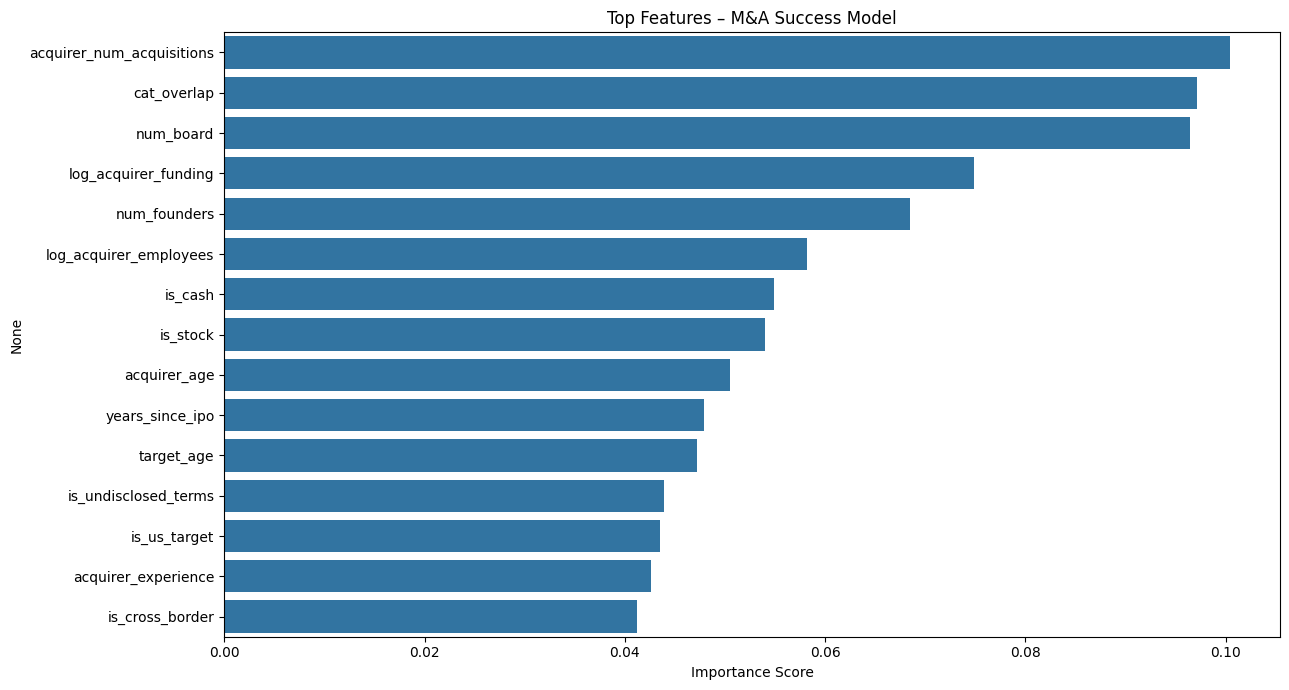

In [12]:
importances = (
    pd.Series(model.feature_importances_, index=features)
    .sort_values(ascending=False)
)

print('Top 15 Features:')
print(importances.head(15))

plt.figure(figsize=(13, 7))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index)
plt.title('Top Features – M&A Success Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 10. Save Output

In [38]:
df.to_csv('mna_features_output.csv', index=False)
print('🎉 Saved: mna_features_output.csv | feature_importance.png')

🎉 Saved: mna_features_output.csv | feature_importance.png


## PREDICTOR

In [ ]:
from datetime import datetime

print('=' * 60)
print('  M&A SUCCESS PREDICTOR — NEW DEAL INPUT')
print('=' * 60)

# ── Acquiring Company ─────────────────────────────────────
print('\n── Acquiring Company ──────────────────────────────────')
acquirer_name         = input('Acquiring company name                    : ').strip()
acquirer_ticker       = input('Stock ticker (blank if private/unknown)   : ').strip().upper() or None
acquirer_founded      = int(input('Year founded                              : ') or 0)
acquirer_ipo_yr       = int(input('IPO year (0 if private)                   : ') or 0)
acquirer_employees    = float(input('Number of employees                       : ') or 0)
acquirer_funding      = float(input('Total funding raised (USD millions)        : ') or 0)
acquirer_num_acqs     = float(input('Total acquisitions made so far            : ') or 0)
acquirer_experience   = float(input('This is acquisition number (serial)       : ') or 0)
acquirer_num_board    = float(input('Number of board members                   : ') or 0)
acquirer_num_founders = float(input('Number of founders                        : ') or 0)
acquirer_desc_input   = input('Brief description / sector (e.g. cloud AI): ').strip()
acquirer_cat_input    = input('Market categories (comma-separated)        : ').strip()

# ── Target Company ────────────────────────────────────────
print('\n── Target Company ─────────────────────────────────────')
target_name        = input('Target company name                        : ').strip()
target_founded     = int(input('Year founded                              : ') or 0)
target_country_inp = input('HQ country (Enter = United States)         : ').strip() or 'United States'
target_desc_input  = input('Brief description / sector                 : ').strip()
target_cat_input   = input('Market categories (comma-separated)        : ').strip()

# ── Deal Details ──────────────────────────────────────────
print('\n── Deal Details ───────────────────────────────────────')
deal_price_m = float(input('Deal price (USD millions, 0 if undisclosed): ') or 0)
terms_input  = input('Payment terms [cash / stock / undisclosed] : ').strip().lower()
deal_year    = int(input('Expected deal year (e.g. 2025)             : ') or datetime.now().year)

print('\n✅ Inputs captured. Running feature engineering...')

  M&A SUCCESS PREDICTOR — NEW DEAL INPUT

── Acquiring Company ──────────────────────────────────

── Target Company ─────────────────────────────────────

── Deal Details ───────────────────────────────────────

✅ Inputs captured. Running feature engineering...


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.metrics.pairwise import cosine_similarity

# ── Price features ────────────────────────────────────────
price_median_val = df['Price'].dropna()
price_median_val = price_median_val[price_median_val > 0].median()
price_filled     = (deal_price_m * 1e6) if deal_price_m > 0 else price_median_val
log_price        = np.log1p(price_filled)

# ── Live market cap from Yahoo Finance ────────────────────
acquirer_mkt_cap = None
if acquirer_ticker:
    try:
        info = yf.Ticker(acquirer_ticker).fast_info
        acquirer_mkt_cap = getattr(info, 'market_cap', None)
        if acquirer_mkt_cap:
            print(f'  Market cap for {acquirer_ticker}: ${acquirer_mkt_cap/1e9:.1f}B')
    except Exception:
        pass

if not acquirer_mkt_cap:
    acquirer_mkt_cap = df['acquirer_mkt_cap'].median()
    print(f'  Ticker not found — using dataset median: ${acquirer_mkt_cap/1e9:.1f}B')

relative_deal_size = price_filled / acquirer_mkt_cap
log_relative_size  = np.log1p(relative_deal_size)

# ── Acquirer features ─────────────────────────────────────
log_acquirer_funding    = np.log1p(acquirer_funding * 1e6)
log_acquirer_employees  = np.log1p(acquirer_employees)
acquirer_age            = max(0, deal_year - acquirer_founded) if acquirer_founded else 0
years_since_ipo         = max(0, deal_year - acquirer_ipo_yr) if acquirer_ipo_yr > 0 else 0
founder_to_board_ratio  = (acquirer_num_founders / acquirer_num_board
                           if acquirer_num_board > 0 else 0)

# ── Target features ───────────────────────────────────────
target_age   = max(0, deal_year - target_founded) if target_founded else 0
is_us_target = int(target_country_inp.strip().lower() in ('united states', 'us', 'usa'))

# ── Payment terms ─────────────────────────────────────────
is_cash              = int('cash' in terms_input)
is_stock             = int(any(w in terms_input for w in ['stock', 'share']))
is_undisclosed_terms = int('undisclosed' in terms_input or terms_input == '')
is_completed         = 0   # deal hasn't happened yet
is_cross_border      = int(not is_us_target)

# ── Text & category relatedness ───────────────────────────
combined_new = (
    acquirer_desc_input + ' ' + target_desc_input + ' ' +
    target_cat_input    + ' ' + acquirer_cat_input
)
vec_new          = tfidf.transform([combined_new])
train_centroid   = np.asarray(tfidf.transform(df['combined_text']).mean(axis=0))
text_relatedness = float(cosine_similarity(vec_new, train_centroid)[0][0])

t_cats      = set(target_cat_input.lower().split(','))
a_words     = set(acquirer_desc_input.lower().split())
cat_overlap = len(t_cats & a_words) / max(len(t_cats), 1)

# ── Build feature row ─────────────────────────────────────
feature_cols = [
    'log_price', 'log_relative_size',
    'acquirer_experience', 'acquirer_num_acquisitions',
    'log_acquirer_funding', 'log_acquirer_employees',
    'target_age', 'acquirer_age', 'years_since_ipo',
    'text_relatedness', 'cat_overlap',
    'is_cash', 'is_stock', 'is_undisclosed_terms', 'is_completed',
    'is_us_target', 'is_cross_border',
    'num_founders', 'num_board', 'founder_to_board_ratio',
] + [col for col in df.columns if col.startswith('size_')]

new_deal_values = {
    'log_price':                 log_price,
    'log_relative_size':         log_relative_size,
    'acquirer_experience':       acquirer_experience,
    'acquirer_num_acquisitions': acquirer_num_acqs,
    'log_acquirer_funding':      log_acquirer_funding,
    'log_acquirer_employees':    log_acquirer_employees,
    'target_age':                target_age,
    'acquirer_age':              acquirer_age,
    'years_since_ipo':           years_since_ipo,
    'text_relatedness':          text_relatedness,
    'cat_overlap':               cat_overlap,
    'is_cash':                   is_cash,
    'is_stock':                  is_stock,
    'is_undisclosed_terms':      is_undisclosed_terms,
    'is_completed':              is_completed,
    'is_us_target':              is_us_target,
    'is_cross_border':           is_cross_border,
    'num_founders':              acquirer_num_founders,
    'num_board':                 acquirer_num_board,
    'founder_to_board_ratio':    founder_to_board_ratio,
}
for col in feature_cols:
    if col not in new_deal_values:
        new_deal_values[col] = 0

X_new = pd.DataFrame([new_deal_values])[feature_cols].fillna(0)
print('✅ Features ready.')

  Market cap for MSFT: $2756.4B
✅ Features ready.


In [ ]:
prob_success = model.predict_proba(X_new)[0][1]
pred_label   = model.predict(X_new)[0]

DIVIDER = '=' * 60
print(f'\n{DIVIDER}')
print(f'  PREDICTION: {acquirer_name} acquires {target_name}')
print(DIVIDER)
print(f'  Success probability : {prob_success:.1%}')
print(f'  Verdict             : {"✅ LIKELY SUCCESSFUL" if pred_label == 1 else "❌ LIKELY UNSUCCESSFUL"}')
print(f'  Confidence          : {"High" if abs(prob_success - 0.5) > 0.2 else "Low — borderline call"}')
print(DIVIDER)

# ── Feature breakdown ─────────────────────────────────────
print('\n── Key inputs used ────────────────────────────────────')
display_map = {
    'Deal price':            f'${price_filled/1e6:.0f}M',
    'Relative deal size':    f'{relative_deal_size:.2%} of acquirer mkt cap',
    'Acquirer market cap':   f'${acquirer_mkt_cap/1e9:.1f}B',
    'Text relatedness':      f'{text_relatedness:.4f}',
    'Category overlap':      f'{cat_overlap:.4f}',
    'Target age (yrs)':      target_age,
    'Acquirer age (yrs)':    acquirer_age,
    'Years since IPO':       years_since_ipo,
    'Prior acquisitions':    acquirer_num_acqs,
    'Serial experience':     acquirer_experience,
    'Payment — cash':        is_cash,
    'Payment — stock':       is_stock,
    'Payment — undisclosed': is_undisclosed_terms,
    'US target':             is_us_target,
    'Board members':         acquirer_num_board,
    'Founders':              acquirer_num_founders,
    'Founder/board ratio':   f'{founder_to_board_ratio:.3f}',
}
for k, v in display_map.items():
    print(f'  {k:<30}: {v}')

# ── Top feature importances for this prediction ────────────
print('\n── Top model features driving this result ─────────────')
imp_series = pd.Series(model.feature_importances_, index=feature_cols)
for feat, imp in imp_series.sort_values(ascending=False).head(8).items():
    val = X_new[feat].values[0]
    print(f'  {feat:<35}: importance={imp:.4f}  value={val:.4f}')

print(f'\n{DIVIDER}')
print('  Model trained on 356 tech M&A deals (1990–2023).')
print('  Success = CAR > 0 on announcement day (market reaction).')
print(f'{DIVIDER}')


  PREDICTION: Microsoft acquires Github
  Success probability : 42.3%
  Verdict             : ❌ LIKELY UNSUCCESSFUL
  Confidence          : Low — borderline call

── Key inputs used ────────────────────────────────────
  Deal price                    : $7500M
  Relative deal size            : 0.27% of acquirer mkt cap
  Acquirer market cap           : $2756.4B
  Text relatedness              : 0.1292
  Category overlap              : 0.0000
  Target age (yrs)              : 10
  Acquirer age (yrs)            : 43
  Years since IPO               : 32
  Prior acquisitions            : 180.0
  Serial experience             : 181.0
  Payment — cash                : 1
  Payment — stock               : 0
  Payment — undisclosed         : 0
  US target                     : 1
  Board members                 : 12.0
  Founders                      : 2.0
  Founder/board ratio           : 0.167

── Top model features driving this result ─────────────
  acquirer_num_acquisitions          : import

In [ ]:
import joblib
import os

# Save model and supporting objects
joblib.dump(model,    'mna_model.pkl')
joblib.dump(tfidf,    'mna_tfidf.pkl')
joblib.dump(features, 'mna_features.pkl')

print("✅ Saved:")
print(f"   mna_model.pkl    — XGBoost classifier  ({os.path.getsize('mna_model.pkl') / 1024:.1f} KB)")
print(f"   mna_tfidf.pkl    — fitted TF-IDF vectorizer")
print(f"   mna_features.pkl — feature name list ({len(features)} features)")

✅ Saved:
   mna_model.pkl    — XGBoost classifier  (925.5 KB)
   mna_tfidf.pkl    — fitted TF-IDF vectorizer
   mna_features.pkl — feature name list (20 features)
